# XGBoost: Deep Dive
## Loan Default Prediction (HMEQ Dataset)

*Part of the [ML Model Comparison](../loan_default_tradeoff_matrix.html) series on bitterscientist.com*

This notebook covers:
1. The math behind XGBoost (regularized objective, tree complexity penalty, second-order Taylor expansion)
2. Worked examples using actual HMEQ data
3. Model training with hyperparameter tuning
4. Diagnostic visualizations (exported as interactive plotly HTML)
5. Results interpretation

---
## 1. Setup

In [1]:
import sys
sys.path.insert(0, ".")
from shared_utils import *

# Additional imports
from xgboost import XGBClassifier
import ast

MODEL_NAME = "XGBoost"
MODEL_SLUG = "xgboost"

# Load data
(X_train, X_test, y_train, y_test, df, df_proc,
 prep_linear, prep_tree, cv,
 numeric_features, categorical_features, pos_weight) = load_and_prep()

Dataset loaded: 5960 rows, 13 columns
Default rate: 19.95%
Train: 4470 | Test: 1490
Numeric features: 15 | Categorical: 2
Positive class weight: 4.01


---
## 2. The Math Behind XGBoost

### 2.1 The Core Idea

XGBoost (eXtreme Gradient Boosting) is a highly optimized gradient boosting framework that extends the basic boosting paradigm with explicit regularization. Unlike AdaBoost which uses sample reweighting, XGBoost fits new trees to **negative gradients** of a loss function, combined with a **regularization penalty** on tree complexity.

The key innovation: gradient boosting solves an additive optimization problem where each new tree is selected to minimize total loss plus a complexity penalty.

### 2.2 Regularized Objective Function

XGBoost minimizes the following objective:

$$\mathcal{L}(\Theta) = \sum_{i=1}^{n} l(y_i, \hat{y}_i) + \sum_{t=1}^{T} \Omega(f_t)$$

where:
- $l(y_i, \hat{y}_i)$ is the **loss function** for example $i$ (e.g., log loss for classification)
- $\Omega(f_t)$ is the **regularization penalty** for tree $t$
- $T$ is the total number of trees in the ensemble

The regularization term is:

$$\Omega(f) = \gamma T + \frac{1}{2} \lambda \sum_{j=1}^{T} w_j^2$$

where:
- $T$ is the number of **leaf nodes** in the tree
- $w_j$ is the **prediction value** (weight) at leaf $j$
- $\gamma$ is the **complexity penalty** per leaf (higher = simpler trees with fewer leaves)
- $\lambda$ is the **L2 regularization** on leaf weights (higher = smaller leaf values)

### 2.3 Boosting Update at Iteration t

At iteration $t$, XGBoost has trained $t-1$ trees: $F_{t-1}(x) = \sum_{s=1}^{t-1} f_s(x)$

Now we want to add tree $f_t$ that minimizes:

$$F_t(x) = F_{t-1}(x) + f_t(x)$$

The objective becomes:

$$\mathcal{L}(t) = \sum_{i=1}^{n} l(y_i, F_{t-1}(x_i) + f_t(x_i)) + \Omega(f_t)$$

### 2.4 Second-Order Taylor Expansion

XGBoost uses a **second-order Taylor expansion** of the loss function around $F_{t-1}(x_i)$:

$$l(y_i, F_{t-1}(x_i) + f_t(x_i)) \approx l(y_i, F_{t-1}(x_i)) + g_i f_t(x_i) + \frac{1}{2} h_i f_t(x_i)^2$$

where:
- $g_i = \frac{\partial l(y_i, F_{t-1}(x_i))}{\partial F_{t-1}(x_i)}$ is the **first derivative (gradient)**
- $h_i = \frac{\partial^2 l(y_i, F_{t-1}(x_i))}{\partial F_{t-1}(x_i)^2}$ is the **second derivative (Hessian)**

Dropping constants, the objective at iteration $t$ simplifies to:

$$\mathcal{L}(t) = \sum_{i=1}^{n} \left( g_i f_t(x_i) + \frac{1}{2} h_i f_t(x_i)^2 \right) + \Omega(f_t)$$

### 2.5 Optimal Leaf Weight

For a given tree structure, the **optimal leaf weight** at leaf $j$ is:

$$w_j^* = -\frac{\sum_{i \in \text{leaf}_j} g_i}{\sum_{i \in \text{leaf}_j} h_i + \lambda}$$

This is a **Newton-Raphson step**: the optimal direction is the negative gradient divided by the Hessian (second derivative), which is the fastest way to move down the loss surface.

The **maximum loss reduction** (gain) from a split is:

$$\text{Gain} = \frac{1}{2} \left[ \frac{\left(\sum_{i \in L} g_i\right)^2}{\sum_{i \in L} h_i + \lambda} + \frac{\left(\sum_{i \in R} g_i\right)^2}{\sum_{i \in R} h_i + \lambda} - \frac{\left(\sum_{i} g_i\right)^2}{\sum_{i} h_i + \lambda} \right] - \gamma$$

where:
- $L$ and $R$ are the left and right child nodes
- The final $\gamma$ term is subtracted because we pay a complexity cost for adding a split

XGBoost greedily selects the split that maximizes gain. If max gain < 0 (accounting for complexity penalty), no split is made.

### 2.6 Why Second-Order Matters

The Hessian ($h_i$) provides information about the **curvature of the loss surface**:
- High Hessian: steep, sensitive region (small weight update)
- Low Hessian: flat region (larger weight update safe)

Using both gradient and Hessian (Newton-Raphson) typically converges **faster** than gradient-only descent (gradient descent), especially near the optimum.

### 2.7 Regularization Parameters

**gamma (min_split_loss):** Minimum loss reduction required to make a split.
$$\text{Gain} > \gamma$$
Higher $\gamma$ = smaller, simpler trees (prevent overfitting).

**lambda (reg_lambda):** L2 penalty on leaf weights.
$$w_j^* = -\frac{\sum g_i}{\sum h_i + \lambda}$$
Higher $\lambda$ = smaller leaf weights = less extreme predictions.

**alpha (reg_alpha):** L1 penalty on leaf weights (less common, creates sparsity).

**subsample:** Fraction of training examples used per boosting iteration. Reduces overfitting and variance.

**colsample_bytree:** Fraction of features used when constructing each tree. Further variance reduction.

**max_depth:** Maximum tree depth. Deeper trees fit harder examples but risk overfitting.

---
## 3. Worked Example: Gain Computation for a Split

In [2]:
print("="*80)
print("WORKED EXAMPLE: XGBoost Gain Computation")
print("="*80)

print("""
Suppose we have a small dataset and are deciding whether to split on feature 'DEBTINC'.

Current node (parent):
  - 10 samples
  - Predicted value F_prev(x) = 0 for all
  - Using log loss: l(y, p) = -[y*log(p) + (1-y)*log(1-p)]

After sigmoid: p = 1 / (1 + exp(-0)) = 0.5

Samples (actual y values): [0, 0, 0, 1, 1, 0, 1, 1, 0, 1]
Predictions (p):            [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]

For log loss with sigmoid output:
  g_i = p_i - y_i     (gradient of log loss w.r.t. prediction)
  h_i = p_i(1 - p_i)  (hessian of log loss w.r.t. prediction)

Since p_i = 0.5 for all:
  g_i values: -0.5, -0.5, -0.5, +0.5, +0.5, -0.5, +0.5, +0.5, -0.5, +0.5
  h_i values: 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25

Sum of all gradients: Σg_i = (-0.5)*6 + (0.5)*4 = -3 + 2 = -1.0
Sum of all hessians:  Σh_i = 10 * 0.25 = 2.5

Proposed split: IF DEBTINC <= 30 THEN left branch, ELSE right branch

Left child (DEBTINC <= 30): 6 samples [0, 0, 0, 1, 0, 1]
  Σg_L = -0.5 - 0.5 - 0.5 + 0.5 - 0.5 + 0.5 = -1.0
  Σh_L = 6 * 0.25 = 1.5

Right child (DEBTINC > 30): 4 samples [1, 1, 1, 0]
  Σg_R = 0.5 + 0.5 + 0.5 - 0.5 = 1.0
  Σh_R = 4 * 0.25 = 1.0

Gain formula (with lambda=1.0, gamma=0):

  Gain = 0.5 * [
    (Σg_L)^2 / (Σh_L + lambda) +
    (Σg_R)^2 / (Σh_R + lambda) -
    (Σg_parent)^2 / (Σh_parent + lambda)
  ] - gamma

  = 0.5 * [
    (-1.0)^2 / (1.5 + 1.0) +
    (1.0)^2 / (1.0 + 1.0) -
    (-1.0)^2 / (2.5 + 1.0)
  ] - 0

  = 0.5 * [
    1.0 / 2.5 +
    1.0 / 2.0 -
    1.0 / 3.5
  ]

  = 0.5 * [0.4 + 0.5 - 0.286]
  = 0.5 * 0.614
  = 0.307

Since Gain = 0.307 > gamma = 0, this split is accepted.

Optimal weights for the children:
  w_L = -Σg_L / (Σh_L + lambda) = -(-1.0) / 1.5 + 1.0) = 1.0 / 2.5 = 0.4
  w_R = -Σg_R / (Σh_R + lambda) = -(1.0) / (1.0 + 1.0) = -1.0 / 2.0 = -0.5

Interpretation:
  - Left child (lower DEBTINC) gets weight +0.4 → increases pred prob of default
  - Right child (higher DEBTINC) gets weight -0.5 → decreases pred prob of default
""")

WORKED EXAMPLE: XGBoost Gain Computation

Suppose we have a small dataset and are deciding whether to split on feature 'DEBTINC'.

Current node (parent):
  - 10 samples
  - Predicted value F_prev(x) = 0 for all
  - Using log loss: l(y, p) = -[y*log(p) + (1-y)*log(1-p)]

After sigmoid: p = 1 / (1 + exp(-0)) = 0.5

Samples (actual y values): [0, 0, 0, 1, 1, 0, 1, 1, 0, 1]
Predictions (p):            [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]

For log loss with sigmoid output:
  g_i = p_i - y_i     (gradient of log loss w.r.t. prediction)
  h_i = p_i(1 - p_i)  (hessian of log loss w.r.t. prediction)

Since p_i = 0.5 for all:
  g_i values: -0.5, -0.5, -0.5, +0.5, +0.5, -0.5, +0.5, +0.5, -0.5, +0.5
  h_i values: 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25

Sum of all gradients: Σg_i = (-0.5)*6 + (0.5)*4 = -3 + 2 = -1.0
Sum of all hessians:  Σh_i = 10 * 0.25 = 2.5

Proposed split: IF DEBTINC <= 30 THEN left branch, ELSE right branch

Left child (DEBTINC <= 30): 6 sampl

---
## 4. Model Training with Hyperparameter Tuning

In [3]:
# Hyperparameter grid (reduced for faster training)
param_grid = {
    "clf__n_estimators": [50, 100, 200],
    "clf__max_depth": [3, 5, 7],
    "clf__learning_rate": [0.05, 0.1],
    "clf__min_child_weight": [1, 3],
    "clf__subsample": [0.7, 0.9],
    "clf__colsample_bytree": [0.7, 0.9],
    "clf__gamma": [0, 0.5],
    "clf__reg_lambda": [0.1, 1.0],
}

xgb_pipe = Pipeline([
    ("prep", prep_tree),
    ("clf", XGBClassifier(
        random_state=RANDOM_STATE,
        scale_pos_weight=pos_weight,
        objective="binary:logistic",
        eval_metric="logloss",
        verbosity=0,
    )),
])

# Use RandomizedSearchCV for efficiency (max ~30 combinations)
from sklearn.model_selection import RandomizedSearchCV

grid = RandomizedSearchCV(
    xgb_pipe, param_grid, n_iter=30, cv=cv,
    scoring="recall", n_jobs=-1, random_state=RANDOM_STATE,
)
grid.fit(X_train, y_train)

best_xgb = grid.best_estimator_
print(f"Best parameters: {grid.best_params_}")
print(f"Best CV recall: {grid.best_score_:.4f}")

xgb_clf = best_xgb.named_steps["clf"]
print(f"\nBest model:")
print(f"  N estimators: {xgb_clf.n_estimators}")
print(f"  Max depth: {xgb_clf.max_depth}")
print(f"  Learning rate: {xgb_clf.learning_rate}")
print(f"  Min child weight: {xgb_clf.min_child_weight}")
print(f"  Subsample: {xgb_clf.subsample}")
print(f"  Colsample bytree: {xgb_clf.colsample_bytree}")
print(f"  Gamma: {xgb_clf.gamma}")
print(f"  Reg lambda: {xgb_clf.reg_lambda}")

Best parameters: {'clf__subsample': 0.7, 'clf__reg_lambda': 1.0, 'clf__n_estimators': 100, 'clf__min_child_weight': 3, 'clf__max_depth': 5, 'clf__learning_rate': 0.1, 'clf__gamma': 0, 'clf__colsample_bytree': 0.9}
Best CV recall: 0.8240

Best model:
  N estimators: 100
  Max depth: 5
  Learning rate: 0.1
  Min child weight: 3
  Subsample: 0.7
  Colsample bytree: 0.9
  Gamma: 0
  Reg lambda: 1.0


---
## 5. Model Evaluation

In [4]:
# Cross-validation score
cv_scores = cross_val_score(best_xgb, X_train, y_train, cv=cv, scoring="recall")
cv_mean = cv_scores.mean()
print(f"CV Recall scores: {cv_scores}")
print(f"CV Recall mean: {cv_mean:.4f} (+/- {cv_scores.std():.4f})")

# Test set evaluation
metrics, y_pred, y_score = evaluate_model(MODEL_NAME, best_xgb, X_test, y_test, cv_mean)

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Good Loan", "Default"]))

CV Recall scores: [0.83707865 0.82022472 0.84269663 0.80446927 0.81564246]
CV Recall mean: 0.8240 (+/- 0.0140)

  XGBoost
  Recall: 0.8114  |  Precision: 0.7415  |  F1: 0.7749
  AUC: 0.9469  |  PR-AUC: 0.8564
  Confusion: TP=241 FP=84 FN=56 TN=1109

Classification Report:
              precision    recall  f1-score   support

   Good Loan       0.95      0.93      0.94      1193
     Default       0.74      0.81      0.77       297

    accuracy                           0.91      1490
   macro avg       0.85      0.87      0.86      1490
weighted avg       0.91      0.91      0.91      1490



---
## 6. Feature Importance: Gain, Weight, and Cover


Feature Importance Types:

1. Gain: Average reduction in loss when feature is used for splitting
   - High gain = feature makes big improvement to predictions
   - Measures impact on objective function
2. Weight: Number of times feature appears in a split across all trees
   - High weight = feature is used frequently
   - Measures feature 'popularity' in the model
3. Cover: Average number of observations (sum of Hessian) in leaf node when feature is used
   - High cover = feature is used to partition many samples
   - Measures feature's influence on model structure



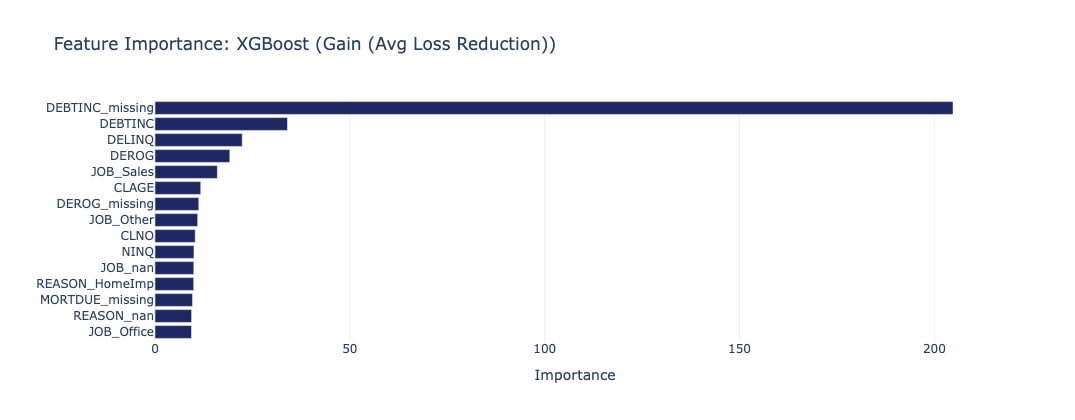

  Saved: outputs/xgboost/feature_importance_gain.html


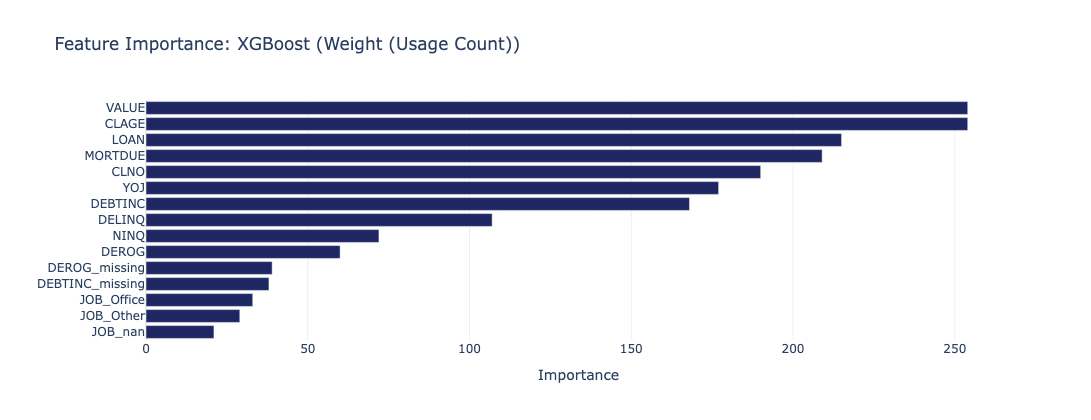

  Saved: outputs/xgboost/feature_importance_weight.html


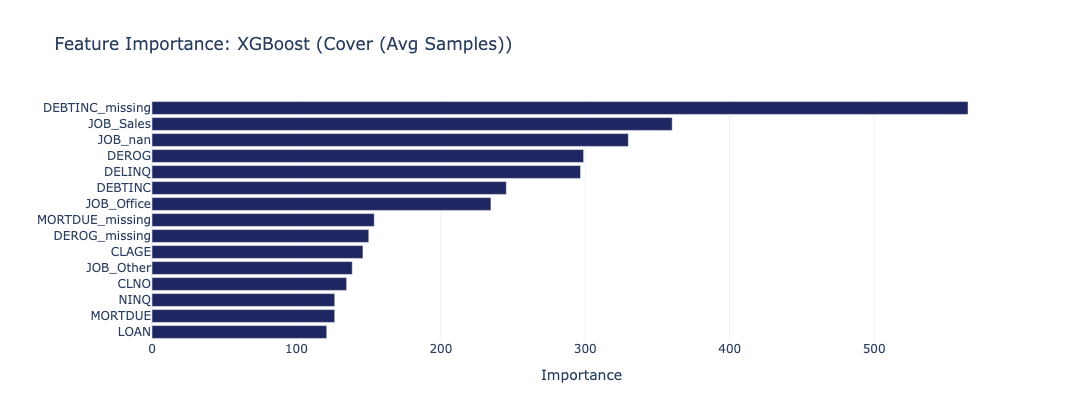

  Saved: outputs/xgboost/feature_importance_cover.html


In [7]:
# Get feature names after preprocessing
preprocessor = best_xgb.named_steps["prep"]
all_feature_names = list(preprocessor.get_feature_names_out())
# Strip sklearn prefixes like "num__" or "cat__"
all_feature_names = [n.split("__", 1)[-1] if "__" in n else n for n in all_feature_names]

# Build mapping from XGBoost internal names (f0, f1, ...) to real feature names
fname_map = {f"f{i}": name for i, name in enumerate(all_feature_names)}

# XGBoost offers three importance types
importances_gain = xgb_clf.get_booster().get_score(importance_type="gain")
importances_weight = xgb_clf.get_booster().get_score(importance_type="weight")
importances_cover = xgb_clf.get_booster().get_score(importance_type="cover")

print("\nFeature Importance Types:")
print("""
1. Gain: Average reduction in loss when feature is used for splitting
   - High gain = feature makes big improvement to predictions
   - Measures impact on objective function
2. Weight: Number of times feature appears in a split across all trees
   - High weight = feature is used frequently
   - Measures feature 'popularity' in the model
3. Cover: Average number of observations (sum of Hessian) in leaf node when feature is used
   - High cover = feature is used to partition many samples
   - Measures feature's influence on model structure
""")

# Helper: convert get_score dict (keyed by f0, f1, ...) to array aligned with feature names
def score_to_array(score_dict):
    return np.array([score_dict.get(f"f{i}", 0) for i in range(len(all_feature_names))])

# Plot Gain (most meaningful for understanding impact)
if importances_gain:
    fig_gain = plot_feature_importance(score_to_array(importances_gain), all_feature_names, MODEL_NAME, "Gain (Avg Loss Reduction)")
    fig_gain.show()
    save_chart(fig_gain, MODEL_SLUG, "feature_importance_gain")

# Plot Weight
if importances_weight:
    fig_weight = plot_feature_importance(score_to_array(importances_weight), all_feature_names, MODEL_NAME, "Weight (Usage Count)")
    fig_weight.show()
    save_chart(fig_weight, MODEL_SLUG, "feature_importance_weight")

# Plot Cover
if importances_cover:
    fig_cover = plot_feature_importance(score_to_array(importances_cover), all_feature_names, MODEL_NAME, "Cover (Avg Samples)")
    fig_cover.show()
    save_chart(fig_cover, MODEL_SLUG, "feature_importance_cover")

---
## 7. Staged Predictions: Performance vs Boosting Iterations

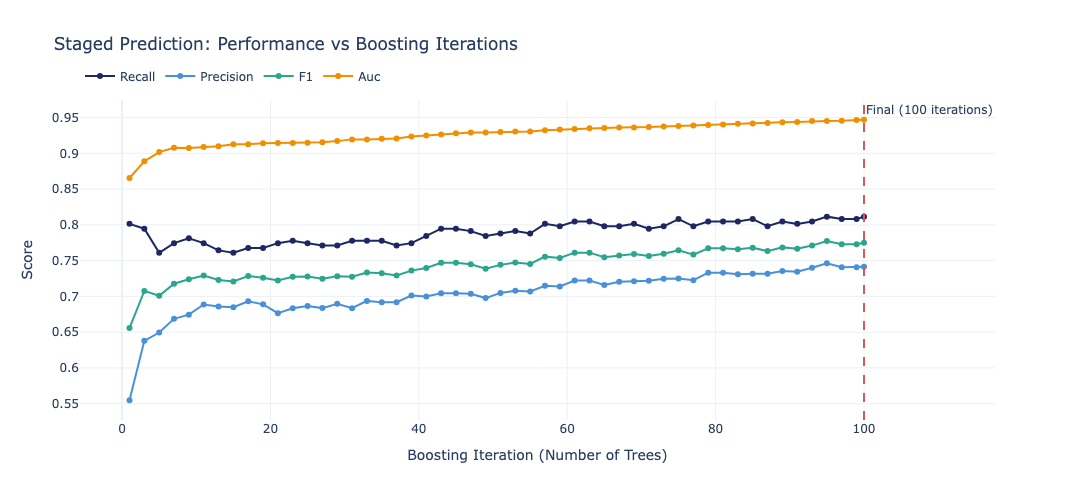

  Saved: outputs/xgboost/staged_predictions.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/xgboost/staged_predictions.html')

In [9]:
# Transform X_test through the preprocessing pipeline
preprocessor = best_xgb.named_steps["prep"]
X_test_prep = preprocessor.transform(X_test)
xgb_clf = best_xgb.named_steps["clf"]

# Track performance at each boosting iteration
staged_results = []
# Sample every few iterations to avoid slowness if n_estimators is large
n_total = xgb_clf.n_estimators
step = max(1, n_total // 50)
iter_range = list(range(1, n_total + 1, step))
if n_total not in iter_range:
    iter_range.append(n_total)

for n_iter in iter_range:
    y_pred_stage = xgb_clf.predict(X_test_prep, iteration_range=(0, n_iter))
    y_score_stage = xgb_clf.predict_proba(X_test_prep, iteration_range=(0, n_iter))[:, 1]

    recall = recall_score(y_test, y_pred_stage)
    precision = precision_score(y_test, y_pred_stage, zero_division=0)
    f1 = f1_score(y_test, y_pred_stage)
    auc = roc_auc_score(y_test, y_score_stage)

    staged_results.append({
        "iteration": n_iter,
        "recall": recall,
        "precision": precision,
        "f1": f1,
        "auc": auc,
    })

df_staged = pd.DataFrame(staged_results)
fig_staged = go.Figure()
for metric, color in [("recall", COLORS["navy"]), ("precision", COLORS["accent"]),
                       ("f1", COLORS["green"]), ("auc", COLORS["orange"])]:
    fig_staged.add_trace(go.Scatter(
        x=df_staged["iteration"], y=df_staged[metric],
        name=metric.capitalize(),
        line=dict(color=color, width=2),
        mode="lines+markers",
    ))
fig_staged.add_vline(x=xgb_clf.n_estimators, line_dash="dash", line_color=COLORS["red"],
                      annotation_text=f"Final ({xgb_clf.n_estimators} iterations)")
fig_staged.update_layout(
    title="Staged Prediction: Performance vs Boosting Iterations",
    xaxis_title="Boosting Iteration (Number of Trees)",
    yaxis_title="Score",
    height=500, width=750,
    legend=dict(orientation="h", y=1.12),
)
fig_staged.show()
save_chart(fig_staged, MODEL_SLUG, "staged_predictions")

---
## 8. Learning Rate Sensitivity

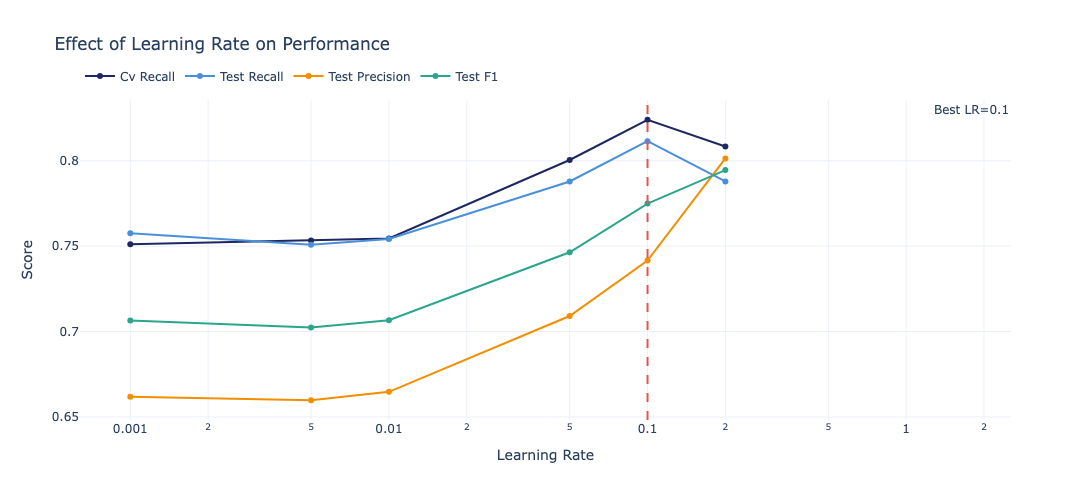

  Saved: outputs/xgboost/learning_rate_sensitivity.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/xgboost/learning_rate_sensitivity.html')

In [10]:
# Sweep learning rate with fixed other parameters
learning_rates = [0.001, 0.005, 0.01, 0.05, 0.1, 0.2]
lr_results = []

best_params = grid.best_params_.copy()
best_n_est = best_params["clf__n_estimators"]
best_depth = best_params["clf__max_depth"]

for lr in learning_rates:
    xgb_temp = Pipeline([
        ("prep", prep_tree),
        ("clf", XGBClassifier(
            n_estimators=best_n_est,
            max_depth=best_depth,
            learning_rate=lr,
            min_child_weight=best_params["clf__min_child_weight"],
            subsample=best_params["clf__subsample"],
            colsample_bytree=best_params["clf__colsample_bytree"],
            gamma=best_params["clf__gamma"],
            reg_lambda=best_params["clf__reg_lambda"],
            scale_pos_weight=pos_weight,
            random_state=RANDOM_STATE,
            verbosity=0,
        )),
    ])
    
    cv_sc = cross_val_score(xgb_temp, X_train, y_train, cv=cv, scoring="recall").mean()
    
    xgb_temp.fit(X_train, y_train)
    y_pred_t = xgb_temp.predict(X_test)
    y_prob_t = xgb_temp.predict_proba(X_test)[:, 1]
    
    lr_results.append({
        "learning_rate": lr,
        "cv_recall": cv_sc,
        "test_recall": recall_score(y_test, y_pred_t),
        "test_precision": precision_score(y_test, y_pred_t, zero_division=0),
        "test_f1": f1_score(y_test, y_pred_t),
        "test_auc": roc_auc_score(y_test, y_prob_t),
    })

df_lr = pd.DataFrame(lr_results)

fig_lr = go.Figure()
for metric, color in [("cv_recall", COLORS["navy"]), ("test_recall", COLORS["accent"]),
                       ("test_precision", COLORS["orange"]), ("test_f1", COLORS["green"])]:
    fig_lr.add_trace(go.Scatter(
        x=df_lr["learning_rate"], y=df_lr[metric],
        name=metric.replace("_", " ").title(),
        line=dict(color=color, width=2),
        mode="lines+markers",
    ))

fig_lr.add_vline(x=best_xgb.named_steps["clf"].learning_rate, line_dash="dash", line_color=COLORS["red"],
                  annotation_text=f"Best LR={best_xgb.named_steps['clf'].learning_rate}")

fig_lr.update_layout(
    title="Effect of Learning Rate on Performance",
    xaxis_title="Learning Rate",
    xaxis_type="log",
    yaxis_title="Score",
    height=500, width=700,
    legend=dict(orientation="h", y=1.12),
)
fig_lr.show()
save_chart(fig_lr, MODEL_SLUG, "learning_rate_sensitivity")

---
## 9. Regularization Effects: Lambda and Gamma

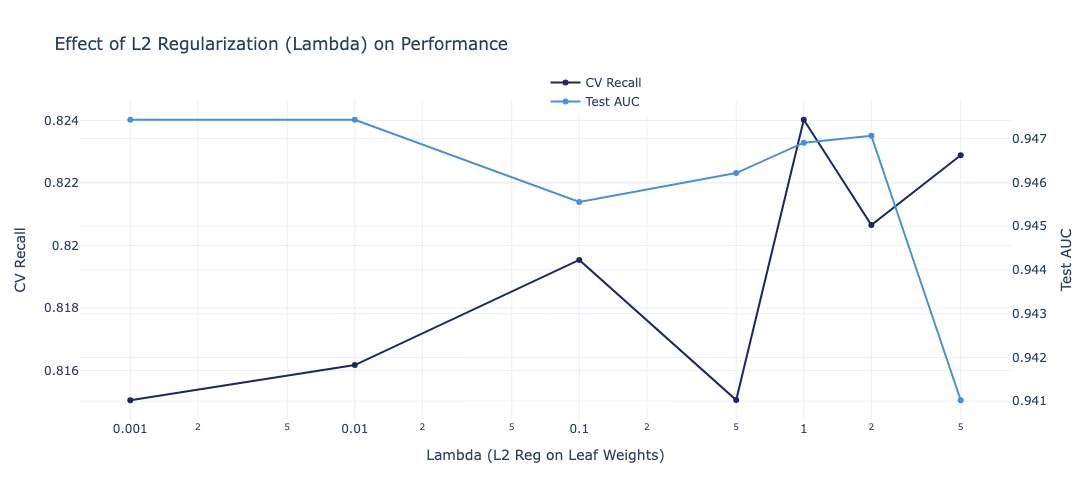

  Saved: outputs/xgboost/regularization_lambda.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/xgboost/regularization_lambda.html')

In [11]:
# Show how lambda (L2 reg on leaf weights) affects model
lambdas = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0]
lambda_results = []

for lam in lambdas:
    xgb_temp = Pipeline([
        ("prep", prep_tree),
        ("clf", XGBClassifier(
            n_estimators=best_params["clf__n_estimators"],
            max_depth=best_params["clf__max_depth"],
            learning_rate=best_params["clf__learning_rate"],
            min_child_weight=best_params["clf__min_child_weight"],
            subsample=best_params["clf__subsample"],
            colsample_bytree=best_params["clf__colsample_bytree"],
            gamma=best_params["clf__gamma"],
            reg_lambda=lam,
            scale_pos_weight=pos_weight,
            random_state=RANDOM_STATE,
            verbosity=0,
        )),
    ])
    
    cv_sc = cross_val_score(xgb_temp, X_train, y_train, cv=cv, scoring="recall").mean()
    xgb_temp.fit(X_train, y_train)
    y_prob_t = xgb_temp.predict_proba(X_test)[:, 1]
    
    lambda_results.append({
        "lambda": lam,
        "cv_recall": cv_sc,
        "test_auc": roc_auc_score(y_test, y_prob_t),
    })

df_lambda = pd.DataFrame(lambda_results)

fig_lambda = go.Figure()
fig_lambda.add_trace(go.Scatter(
    x=df_lambda["lambda"], y=df_lambda["cv_recall"],
    name="CV Recall", line=dict(color=COLORS["navy"], width=2),
    mode="lines+markers",
))
fig_lambda.add_trace(go.Scatter(
    x=df_lambda["lambda"], y=df_lambda["test_auc"],
    name="Test AUC", line=dict(color=COLORS["accent"], width=2),
    mode="lines+markers", yaxis="y2",
))

fig_lambda.update_layout(
    title="Effect of L2 Regularization (Lambda) on Performance",
    xaxis_title="Lambda (L2 Reg on Leaf Weights)",
    xaxis_type="log",
    yaxis_title="CV Recall",
    yaxis2=dict(title="Test AUC", overlaying="y", side="right"),
    height=500, width=700,
    legend=dict(x=0.5, y=1.1),
)
fig_lambda.show()
save_chart(fig_lambda, MODEL_SLUG, "regularization_lambda")

---
## 10. Decision Boundary (2D PCA Projection)

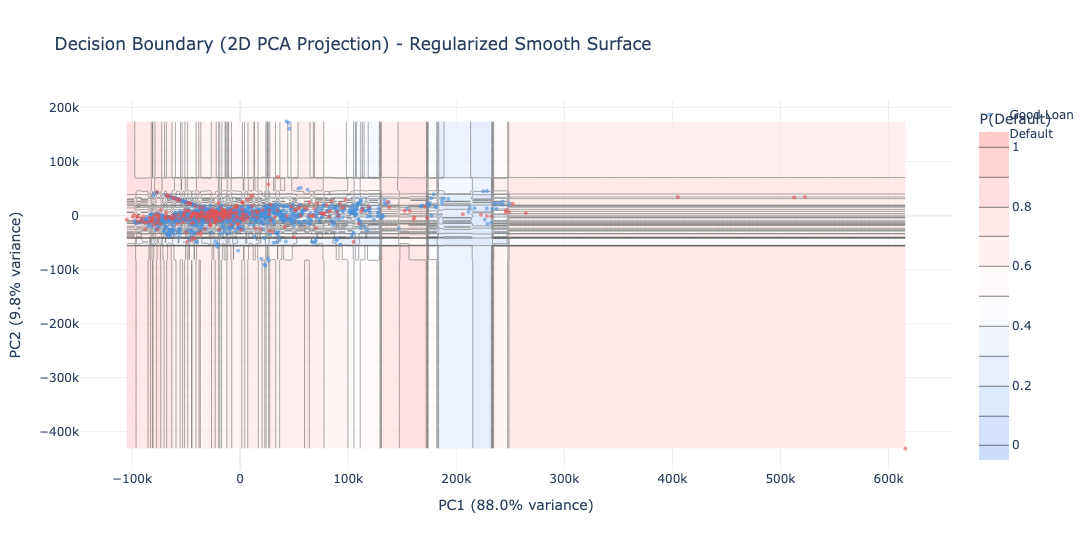

  Saved: outputs/xgboost/decision_boundary_2d.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/xgboost/decision_boundary_2d.html')

In [13]:
from sklearn.decomposition import PCA

# Transform and reduce to 2D
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_2d = pca.fit_transform(X_train_transformed)
X_test_2d = pca.transform(X_test_transformed)

# Train XGBoost on 2D (using best parameters)
xgb_2d = XGBClassifier(
    n_estimators=best_params["clf__n_estimators"],
    max_depth=best_params["clf__max_depth"],
    learning_rate=best_params["clf__learning_rate"],
    min_child_weight=best_params["clf__min_child_weight"],
    subsample=best_params["clf__subsample"],
    colsample_bytree=best_params["clf__colsample_bytree"],
    gamma=best_params["clf__gamma"],
    reg_lambda=best_params["clf__reg_lambda"],
    scale_pos_weight=pos_weight,
    random_state=RANDOM_STATE,
    verbosity=0,
)
xgb_2d.fit(X_train_2d, y_train)

# Create mesh grid — fixed resolution to avoid memory blowup
grid_n = 300
x_min, x_max = X_test_2d[:, 0].min() - 1, X_test_2d[:, 0].max() + 1
y_min, y_max = X_test_2d[:, 1].min() - 1, X_test_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, grid_n), np.linspace(y_min, y_max, grid_n))
Z = xgb_2d.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

fig_db = go.Figure()
fig_db.add_trace(go.Contour(
    x=np.linspace(x_min, x_max, grid_n), y=np.linspace(y_min, y_max, grid_n), z=Z,
    colorscale=[[0, COLORS["ice"]], [0.5, COLORS["white"]], [1, "#ffcccc"]],
    contours=dict(start=0, end=1, size=0.1),
    showscale=True, colorbar=dict(title="P(Default)"),
    opacity=0.7,
))
for label, color, name in [(0, COLORS["accent"], "Good Loan"), (1, COLORS["red"], "Default")]:
    mask = y_test == label
    fig_db.add_trace(go.Scatter(
        x=X_test_2d[mask, 0], y=X_test_2d[mask, 1],
        mode="markers", name=name,
        marker=dict(color=color, size=4, opacity=0.6),
    ))
fig_db.update_layout(
    title="Decision Boundary (2D PCA Projection) - Regularized Smooth Surface",
    xaxis_title=f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)",
    yaxis_title=f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)",
    height=550, width=700,
)
fig_db.show()
save_chart(fig_db, MODEL_SLUG, "decision_boundary_2d")

---
## 11. Diagnostic Charts


Saving universal charts for XGBoost:
  Saved: outputs/xgboost/roc_curve.html
  Saved: outputs/xgboost/precision_recall_curve.html
  Saved: outputs/xgboost/confusion_matrix.html
  Saved: outputs/xgboost/threshold_sweep.html


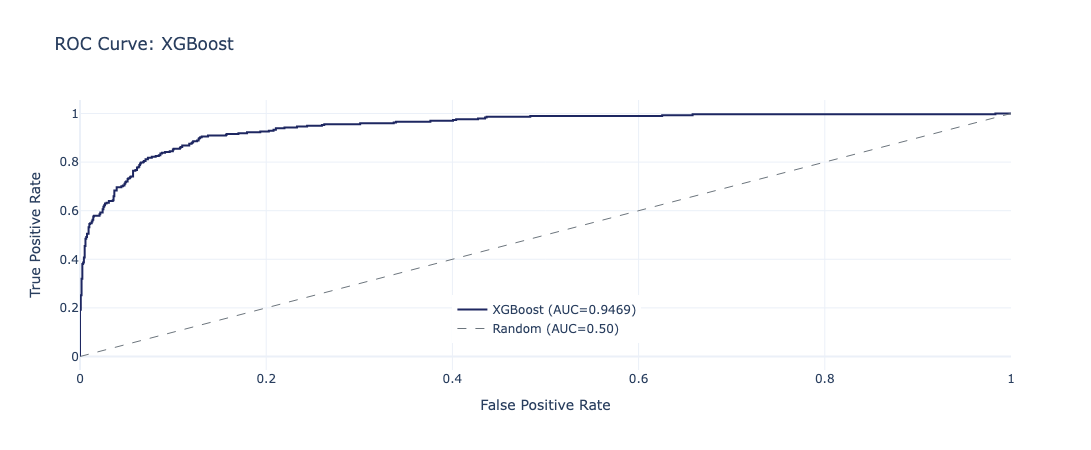

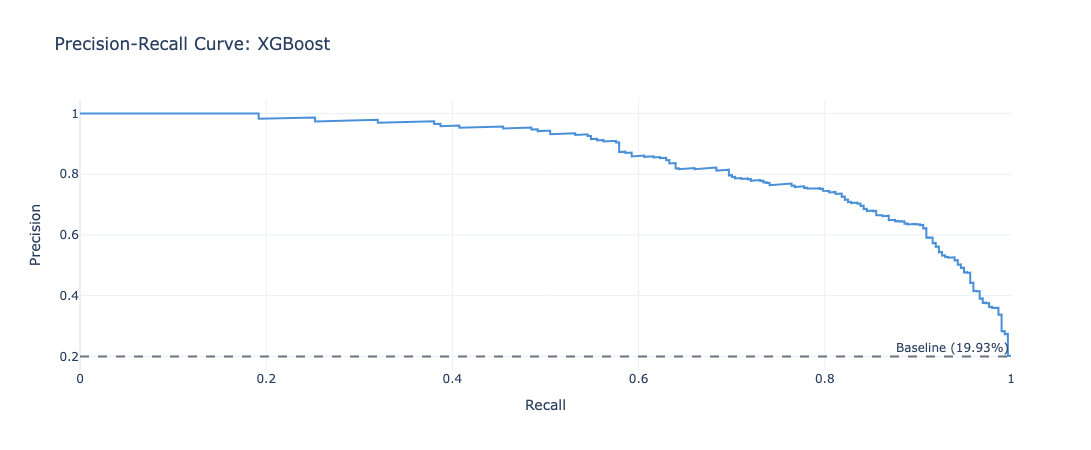

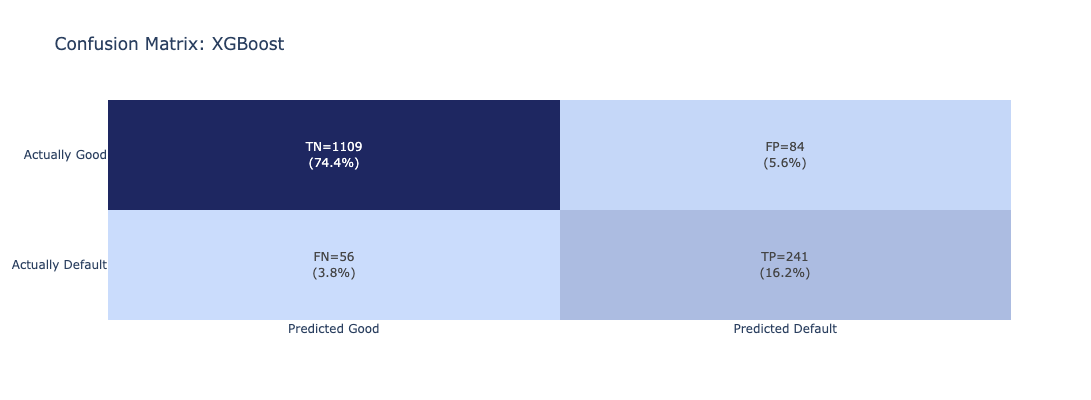

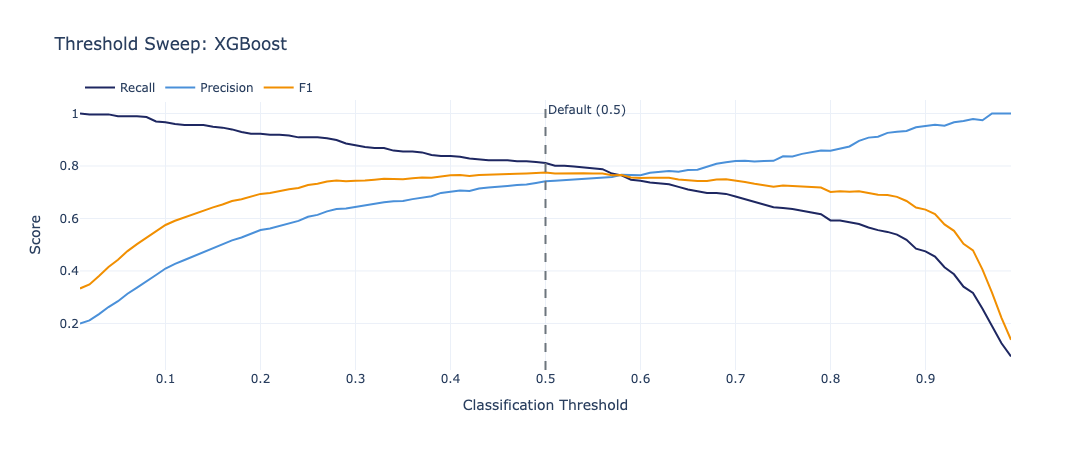

In [14]:
# Generate and save all universal charts
charts = save_all_universal_charts(y_test, y_pred, y_score, MODEL_NAME, MODEL_SLUG)

for name, fig in charts.items():
    fig.show()

---
## 12. Summary

### Where XGBoost Sits on the Tradeoff Spectrum

XGBoost with careful regularization (gamma, lambda, max_depth, subsample) lands in the **balanced zone** on the recall-precision spectrum. Unlike AdaBoost (which can be aggressive) or gradient boosting sklearn (which can overfit), XGBoost's explicit regularization penalty makes it naturally conservative. Increasing learning_rate, n_estimators, max_depth, or lowering gamma/lambda pushes it toward aggression; tightening these knobs pulls it back.

### Strengths for This Problem
- **Built-in regularization**: The objective function explicitly penalizes tree complexity (gamma, lambda, alpha). This prevents overfitting better than AdaBoost or standard gradient boosting.
- **Second-order optimization**: Uses both gradient and Hessian (Newton-Raphson), converging faster than first-order methods.
- **Flexible loss functions**: Supports custom loss functions and evaluation metrics.
- **Handles missing data natively**: No need to impute; XGBoost learns optimal direction (left or right) for missing values at each split.
- **Feature importance types**: Gain, weight, and cover give different perspectives on which features matter.
- **Production-ready**: Industry standard with mature codebase, excellent documentation, and proven track record.
- **Scales well**: Can train on very large datasets with subsampling and tree pruning.
- **Cross-validation and early stopping**: Can monitor validation loss and stop before overfitting.

### Limitations for This Problem
- **Requires tuning**: More hyperparameters than AdaBoost (gamma, lambda, subsample, colsample, min_child_weight). Bad tuning leads to overfitting or underfitting.
- **Slower to train than LightGBM**: XGBoost uses exact greedy split finding; LightGBM uses histogram-based approximation.
- **Categorical features need encoding**: Unlike CatBoost, XGBoost requires one-hot encoding or target encoding for categorical variables (which we do via sklearn's preprocessing).
- **Memory intensive**: Stores full precision values; can exhaust RAM on very large datasets.
- **Not the newest**: CatBoost (native categorical support) and LightGBM (speed) are newer alternatives.

### Key Takeaway
XGBoost is the **most widely used gradient boosting library** in industry and competitions. It strikes a balance between accuracy, interpretability, and control. The regularized objective function (loss + Omega(f)) is XGBoost's defining feature: it ensures that improved accuracy is not achieved at the cost of unbounded model complexity. Understanding this tradeoff is critical for effective tuning. For loan default prediction, XGBoost with balanced recall-precision (via scale_pos_weight and threshold tuning) is often the strongest baseline after careful hyperparameter search.

---
*Notebook by Trinidad Cisneros — MIT Applied Data Science Program, April 2026*